### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:

* **Your name:**                  Hagos Birhane Asfha
* **Your student number:**        1012433779

## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]

For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [10]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

### Step 0 — Prepare the population dataframe

The code below:

1. downloads the required list of 237 countries;
2. keeps only observations from 1901 through 2023;
3. reshapes the data so countries are rows and years are columns; and
4. removes any country containing a missing or non-finite value.

In [11]:
import numpy as np

# Download and clean the official country list.
countries_response = requests.get(countries_list_url, headers=headers)
countries_response.raise_for_status()

countries_list = [
    country.strip()
    for country in countries_response.text.splitlines()
    if country.strip()
]

# Retain only listed countries and the required years.
population_long = raw_data.loc[
    raw_data["entity"].isin(countries_list)
    & raw_data["year"].between(1901, 2023),
    ["entity", "year", "population_historical"]
].copy()

# Reshape to: countries = rows, years = columns.
population_df = population_long.pivot(
    index="entity",
    columns="year",
    values="population_historical"
)

# Remove countries with at least one missing or invalid value.
population_df = (
    population_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=0, how="any")
    .sort_index()
)

print(f"Final dataframe shape: {population_df.shape}")
population_df.head()

Final dataframe shape: (196, 123)


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

### Step 1 — Define the plotting function and figure style

In [12]:
import matplotlib.pyplot as plt

# Global plotting settings for consistent, readable figures.
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "sans-serif",
    "grid.alpha": 0.3
})

In [13]:
def plot_country_timeseries(dataframe, countries, title_prefix="", y_label="Value"):
    """Plot one time-series subplot for each selected country.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Rows are countries and columns are years.
    countries : list of str
        Country names to plot.
    title_prefix : str, optional
        Text placed before each country name in the subplot title.
    y_label : str, optional
        Label for the vertical axis.
    """
    missing_countries = [
        country for country in countries
        if country not in dataframe.index
    ]
    if missing_countries:
        raise ValueError(
            f"Countries not found in dataframe: {missing_countries}"
        )

    n_countries = len(countries)
    fig, axes = plt.subplots(
        n_countries,
        1,
        figsize=(12, 3 * n_countries),
        sharex=True
    )

    if n_countries == 1:
        axes = [axes]

    for ax, country in zip(axes, countries):
        ax.plot(
            dataframe.columns,
            dataframe.loc[country],
            linewidth=2
        )
        ax.set_title(f"{title_prefix}{country}")
        ax.set_ylabel(y_label)
        ax.grid(True)

    axes[-1].set_xlabel("Year")
    plt.tight_layout()
    plt.show()

### Step 2 — Standardize yearly population values

In [14]:
from sklearn.preprocessing import StandardScaler

# StandardScaler works column by column. Each year is therefore standardized
# across all retained countries to have mean 0 and population standard deviation 1.
scaler = StandardScaler()
standardized_values = scaler.fit_transform(population_df)

standardized_df = pd.DataFrame(
    standardized_values,
    index=population_df.index,
    columns=population_df.columns
)

# Verify the result using population standard deviation (ddof=0),
# which is consistent with StandardScaler.
standardization_check = pd.DataFrame({
    "mean": standardized_df.mean(axis=0),
    "std": standardized_df.std(axis=0, ddof=0)
}).round(2)

# Replace the cosmetic display value -0.0 with 0.0.
standardization_check["mean"] = standardization_check["mean"].mask(
    standardization_check["mean"].abs() < 0.005,
    0.0
)

standardization_check.head()

,mean,std
year,,
1901,0.0,1.0
1902,0.0,1.0
1903,0.0,1.0
1904,0.0,1.0
1905,0.0,1.0


### Step 3 — Find the country names closest to the first name

Levenshtein distance is the minimum number of single-character insertions, deletions, or substitutions needed to transform one string into another.

In [15]:
try:
    import Levenshtein
except ImportError:
    !pip -q install python-Levenshtein
    import Levenshtein

first_name = "Hagos"

country_distances = [
    (
        country,
        Levenshtein.distance(first_name.lower(), country.lower())
    )
    for country in population_df.index
]

closest_countries = sorted(
    country_distances,
    key=lambda item: (item[1], item[0])
)[:2]

closest_countries

[('Laos', 2), ('Gabon', 3)]

The two closest country names are **Laos** (distance 2) and **Gabon** (distance 3).

### Step 4 — Plot the original and standardized time-series

The selected countries are the two identified above, together with Japan, Bosnia and Herzegovina, Latvia, and the United Arab Emirates.

In [16]:
closest_country_names = [country for country, distance in closest_countries]

required_countries = [
    "Japan",
    "Bosnia and Herzegovina",
    "Latvia",
    "United Arab Emirates"
]

# Preserve order while preventing accidental duplicates.
countries_to_plot = list(dict.fromkeys(closest_country_names + required_countries))
countries_to_plot

['Laos',
 'Gabon',
 'Japan',
 'Bosnia and Herzegovina',
 'Latvia',
 'United Arab Emirates']

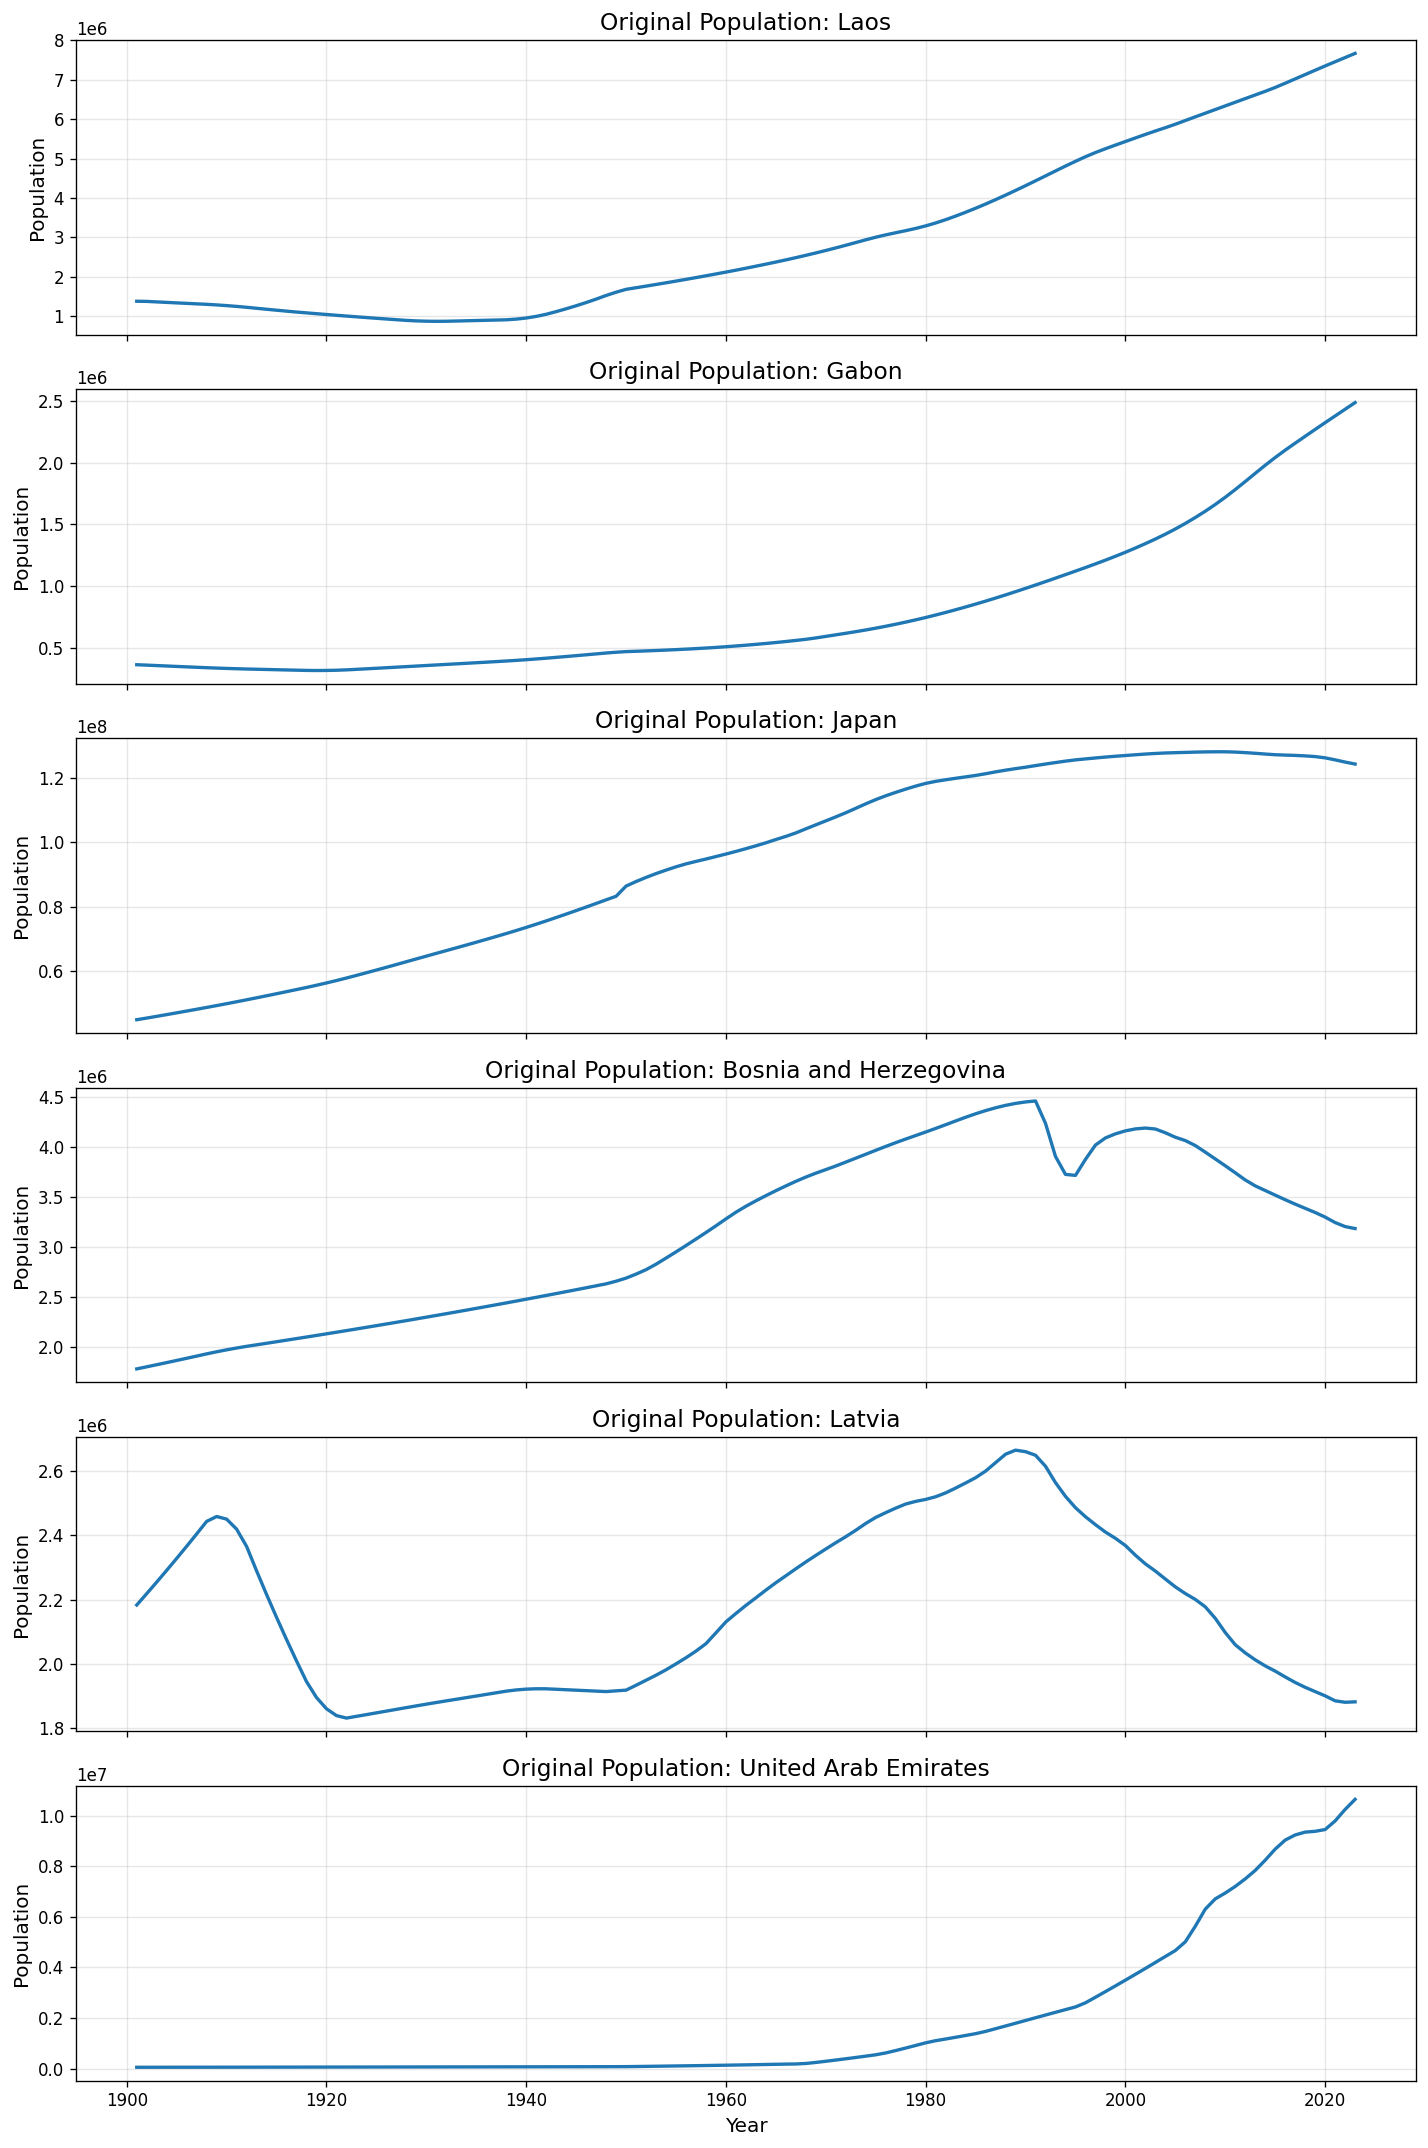

In [17]:
plot_country_timeseries(
    population_df,
    countries_to_plot,
    title_prefix="Original Population: ",
    y_label="Population"
)

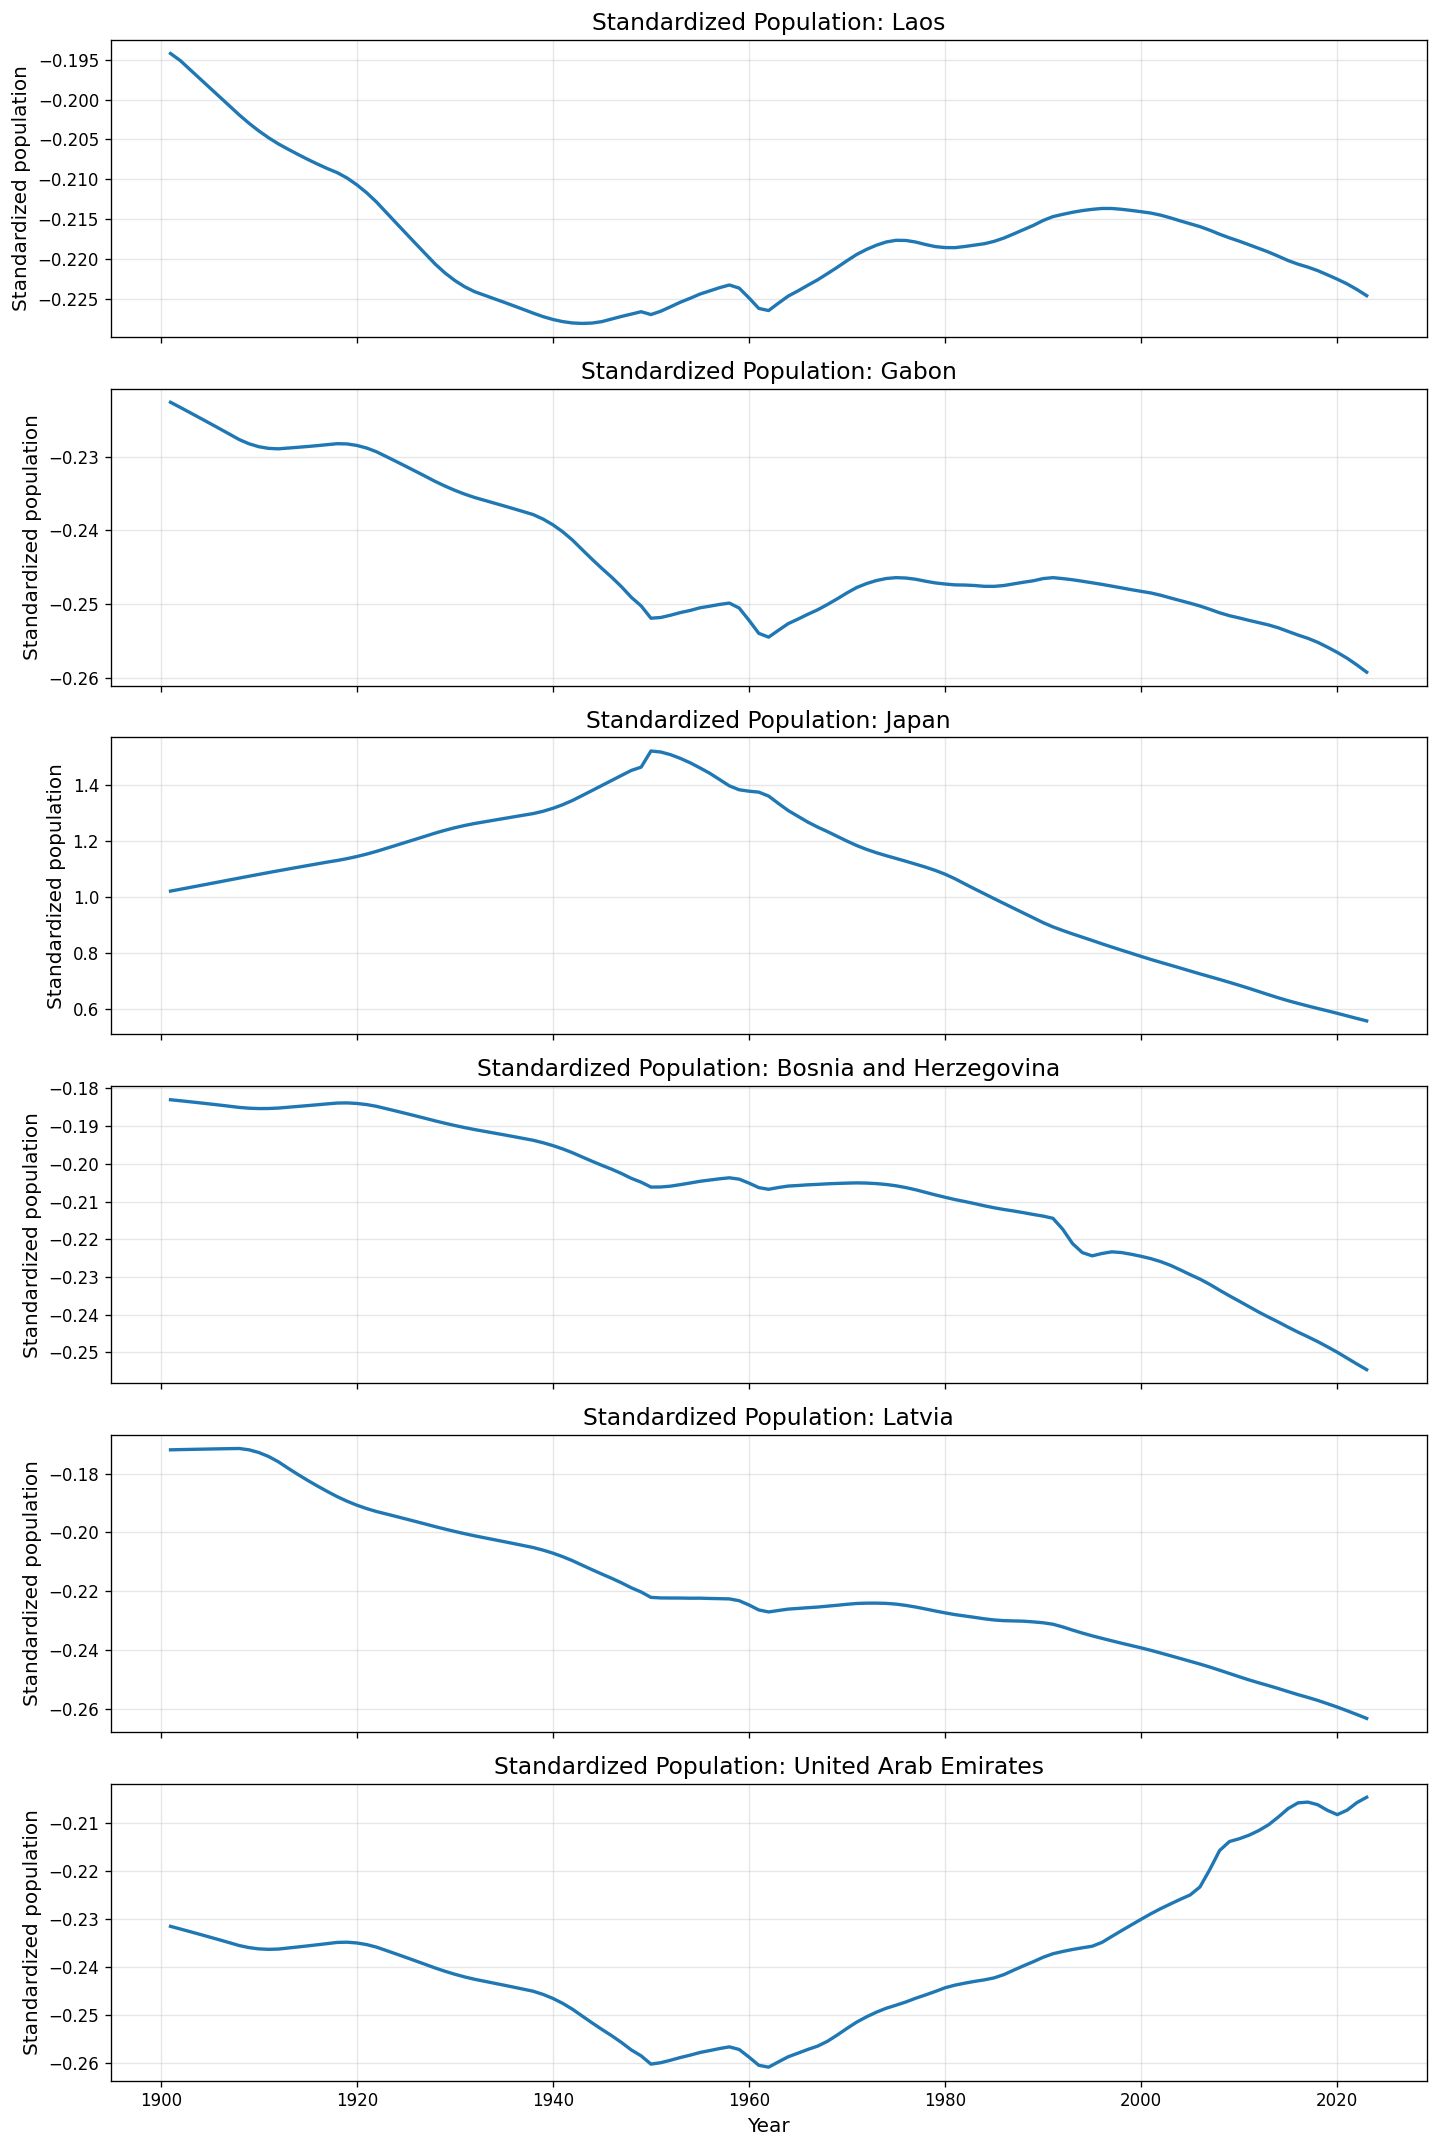

In [18]:
plot_country_timeseries(
    standardized_df,
    countries_to_plot,
    title_prefix="Standardized Population: ",
    y_label="Standardized population"
)

### Step 5. Discussion of the standardized time-series

- For every year, standardization compares each country's population with the distribution of populations across all retained countries in that same year. A value of zero represents the yearly mean. A positive value means that the country's population is above that mean, while a negative value means it is below the mean. The magnitude indicates the distance from the mean in standard-deviation units.

- An upward standardized curve does **not** simply mean that the country's population increased. It means that the country's population increased relative to the yearly cross-country distribution. Similarly, a downward curve means that the country lost relative position, even when its absolute population may still have grown.

- **Japan** remains positive throughout the period, showing that its population is consistently well above the yearly country average. Its standardized score rises until approximately the middle of the twentieth century and then declines, indicating that Japan's population subsequently grew more slowly than the cross-country average and later began to decrease in absolute terms.

- **Laos** and **Gabon** remain negative because their populations are below the yearly mean. Although both countries grow substantially in absolute population, their standardized curves generally decline over the full period. This indicates that the mean and spread of country populations increased faster than their relative position.

- **Bosnia and Herzegovina** and **Latvia** also remain below the yearly mean and show pronounced downward standardized trends, particularly in recent decades. Their relative positions therefore weakened compared with the distribution of country populations.

- The **United Arab Emirates** remains below the yearly mean but shows a strong upward trend from approximately the 1960s onward. This means that its population grew much faster than the cross-country benchmark, substantially improving its relative position even though its standardized values remain negative.